# Step 3: Markov Bias Injection

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving qci_qrng_data_121mil.bin to qci_qrng_data_121mil.bin


In [ ]:
combined_output_path = "/content/combined_121M_qci.bin"
with open(combined_output_path, "wb") as f:
    f.write(data.tobytes())

print("✅ Combined file saved at:", combined_output_path)

✅ Combined file saved at: /content/combined_121M_qci.bin


In [ ]:
import numpy as np

def markovify_bytes(data, max_step=3, seed=None):
    rng = np.random.default_rng(seed)
    out = np.empty_like(data)
    out[0] = data[0]  # keep first byte

    for i in range(1, len(data)):
        # Keep strong correlation with previous byte
        step = rng.integers(-max_step, max_step + 1)
        new_val = int(out[i-1]) + step
        new_val = np.clip(new_val, 0, 255)  # ensure valid byte range
        out[i] = new_val

    return out

# Apply Markov dependency
markov_bytes = markovify_bytes(data, max_step=3, seed=42)

print("Generated Markov byte stream:", markov_bytes.shape)


Generated Markov byte stream: (121000000,)


In [ ]:
markov_output_path = "/content/markov_121M_qci.bin"

with open(markov_output_path, "wb") as f:
    f.write(markov_bytes.tobytes())

print("Saved file size:", markov_bytes.size, "bytes")
print("Markov-biased file saved at:", markov_output_path)

Saved file size: 121000000 bytes
Markov-biased file saved at: /content/markov_121M_qci.bin


In [ ]:
print("Original Data:")
print(" Mean:", np.mean(data))
print(" Std Dev:", np.std(data))

print("\nMarkov Biased Data:")
print(" Mean:", np.mean(markov_bytes))
print(" Std Dev:", np.std(markov_bytes))

Original Data:
 Mean: 127.49544232061069
 Std Dev: 73.90298791131467

Markov Biased Data:
 Mean: 127.50365454198473
 Std Dev: 74.09635858347787


In [ ]:
corr_original = np.corrcoef(data[:-1], data[1:])[0,1]
corr_markov = np.corrcoef(markov_bytes[:-1], markov_bytes[1:])[0,1]

print("Autocorrelation Original:", corr_original)
print("Autocorrelation Markov: ", corr_markov)


Autocorrelation Original: 6.356627292990957e-05
Autocorrelation Markov:  0.9996395506403075


Loaded Original Bytes: 131000000
Loaded Markov Bytes: 131000000


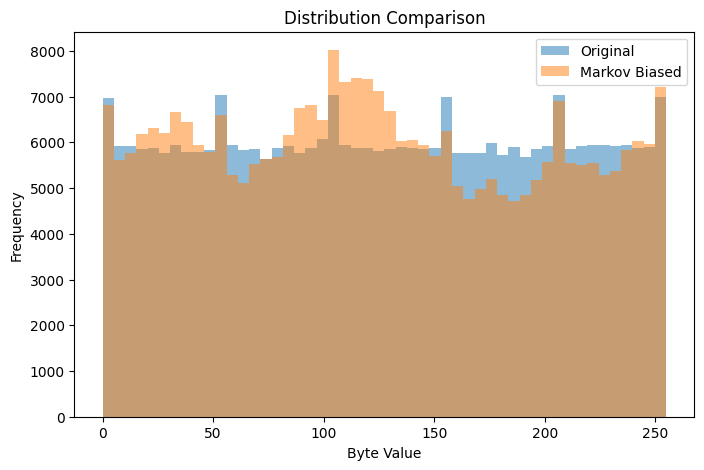

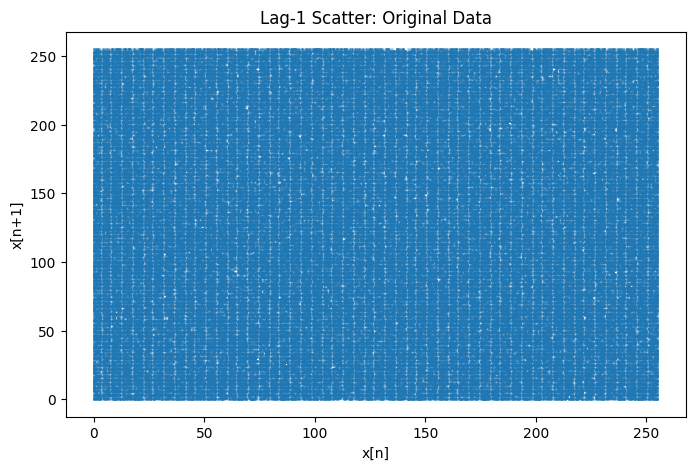

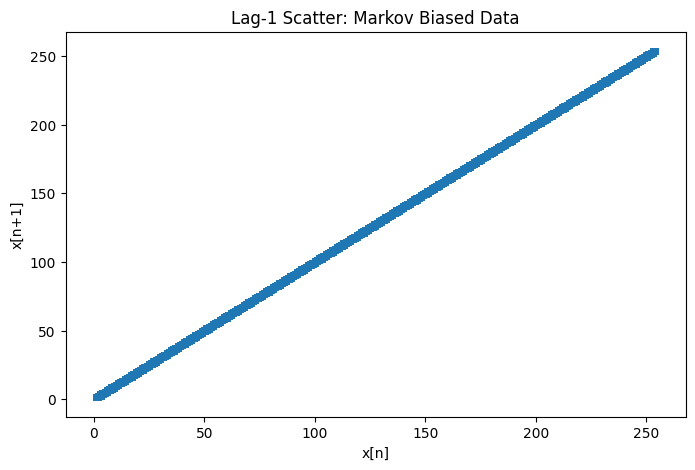

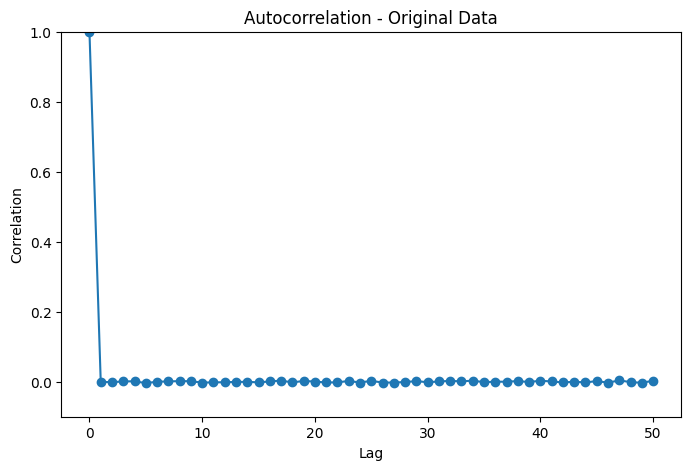

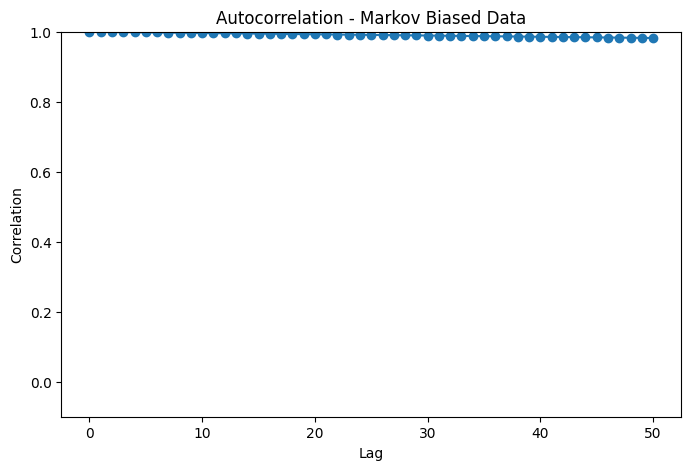

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

#Load original & Markov-biased data from saved .bin files
original_path = "/content/combined_131M_random.bin"
markov_path = "/content/markov_131M.bin"

data = np.fromfile(original_path, dtype=np.uint8)
markov_bytes = np.fromfile(markov_path, dtype=np.uint8)

print("Loaded Original Bytes:", data.size)
print("Loaded Markov Bytes:", markov_bytes.size)

# Use smaller chunk for fast visualization
subset_size = 300000
orig = data[:subset_size]
markov = markov_bytes[:subset_size]

# 1️. Histogram Comparison
plt.figure(figsize=(8,5))
plt.hist(orig, bins=50, alpha=0.5, label="Original")
plt.hist(markov, bins=50, alpha=0.5, label="Markov Biased")
plt.xlabel("Byte Value")
plt.ylabel("Frequency")
plt.title("Distribution Comparison")
plt.legend()
plt.show()

# 2️. Lag-1 Scatter Plots (Shows Markov Correlation)
plt.figure(figsize=(8,5))
plt.scatter(orig[:-1], orig[1:], s=1, alpha=0.3)
plt.title("Lag-1 Scatter: Original Data")
plt.xlabel("x[n]")
plt.ylabel("x[n+1]")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(markov[:-1], markov[1:], s=1, alpha=0.3)
plt.title("Lag-1 Scatter: Markov Biased Data")
plt.xlabel("x[n]")
plt.ylabel("x[n+1]")
plt.show()

# 3️. Autocorrelation Plot (Most important proof)
lags = 50
acf_orig = acf(orig, nlags=lags, fft=True)
acf_markov = acf(markov, nlags=lags, fft=True)

plt.figure(figsize=(8,5))
plt.plot(acf_orig, marker="o")
plt.title("Autocorrelation - Original Data")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.ylim([-0.1, 1])
plt.show()

plt.figure(figsize=(8,5))
plt.plot(acf_markov, marker="o")
plt.title("Autocorrelation - Markov Biased Data")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.ylim([-0.1, 1])
plt.show()

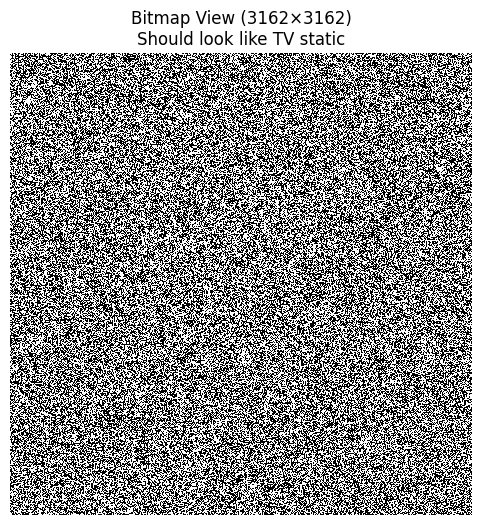

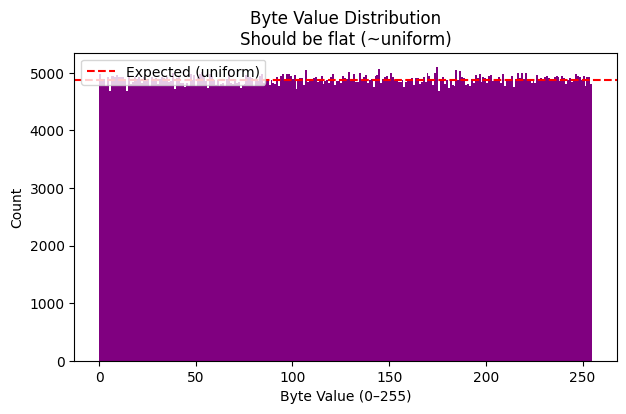

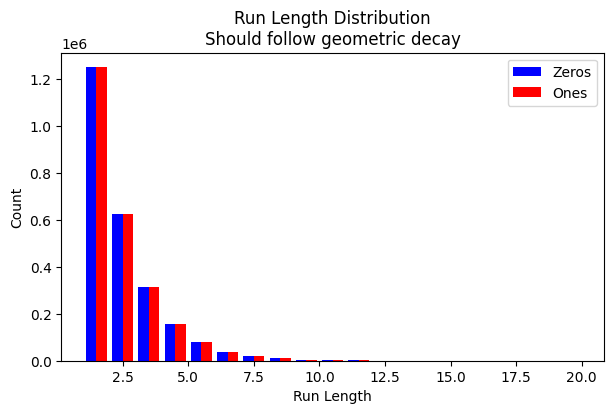

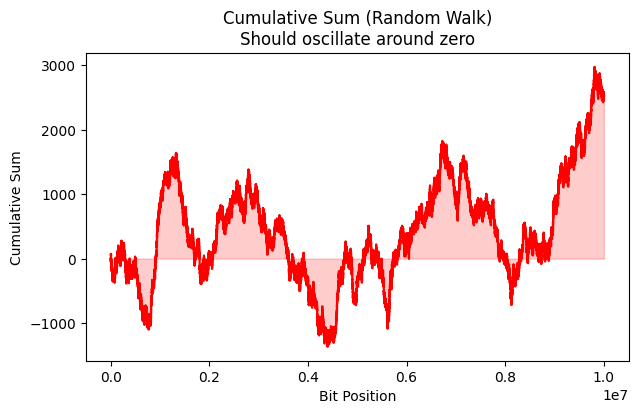

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load binary file ---
filename = "/content/combined_131M_random.bin"
sample_bits = 10_000_000

# --- Load limited bytes ---
sample_bytes = sample_bits // 8
byte_data = np.fromfile(filename, dtype=np.uint8, count=sample_bytes)

# Convert bytes to bits (0/1)
bits = np.unpackbits(byte_data)

# 1. Bitmap View (like TV static)
size = int(np.sqrt(len(bits)))
img = bits[:size*size].reshape((size, size))

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray', interpolation='nearest')
plt.title('Bitmap View ({}×{})\nShould look like TV static'.format(size, size))
plt.axis('off')
plt.show()

# 2. Byte Value Distribution
plt.figure(figsize=(7, 4))
plt.hist(byte_data, bins=256, range=(0, 255), color='purple')
plt.axhline(len(byte_data)/256, color='r', linestyle='--', label='Expected (uniform)')
plt.title('Byte Value Distribution\nShould be flat (~uniform)')
plt.xlabel('Byte Value (0–255)')
plt.ylabel('Count')
plt.legend()
plt.show()

# 3. Run Length Distribution
def run_lengths(bits):
    """Return run lengths for 0s and 1s separately."""
    diffs = np.diff(bits)
    run_ends = np.where(diffs != 0)[0] + 1
    runs = np.diff(np.concatenate(([0], run_ends, [len(bits)])))
    values = bits[np.concatenate(([0], run_ends))]
    return runs, values

runs, vals = run_lengths(bits)
zeros = runs[vals == 0]
ones = runs[vals == 1]

plt.figure(figsize=(7, 4))
plt.hist([zeros, ones], bins=np.arange(1, 21), label=['Zeros', 'Ones'], color=['blue', 'red'])
plt.title('Run Length Distribution\nShould follow geometric decay')
plt.xlabel('Run Length')
plt.ylabel('Count')
plt.legend()
plt.show()

# 4. Cumulative Sum (Random Walk)
# Convert bits: 1 → +1, 0 → -1
walk = np.where(bits == 1, 1, -1)
cum_sum = np.cumsum(walk)

plt.figure(figsize=(7, 4))
plt.plot(cum_sum, color='r')
plt.fill_between(np.arange(len(cum_sum)), cum_sum, color='r', alpha=0.2)
plt.title('Cumulative Sum (Random Walk)\nShould oscillate around zero')
plt.xlabel('Bit Position')
plt.ylabel('Cumulative Sum')
plt.show()

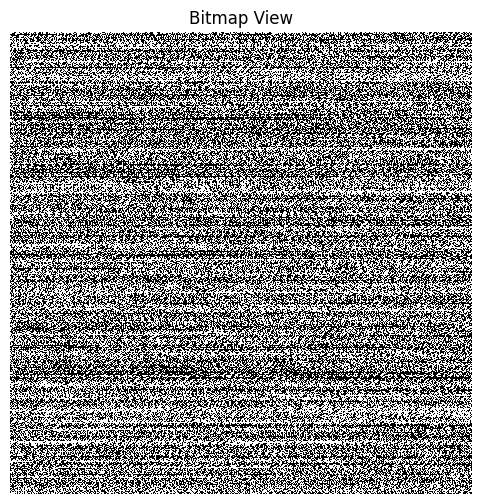

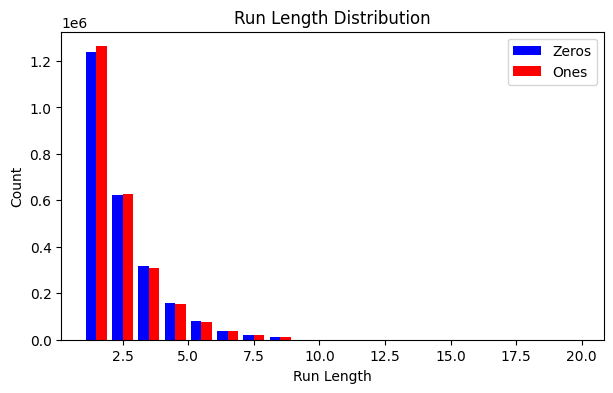

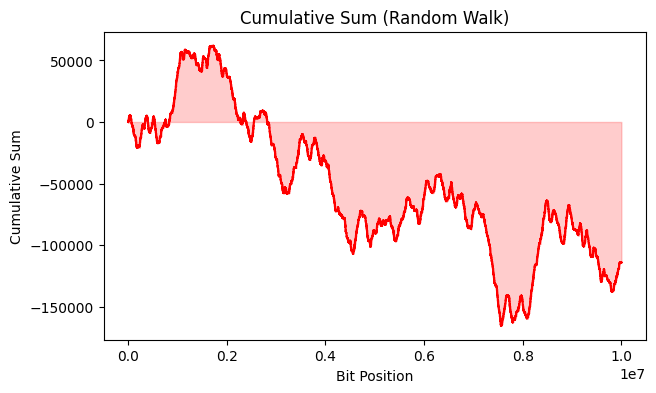

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load binary file ---
filename = "/content/markov_131M.bin"  # replace with your actual path
sample_bits = 10_000_000  # ✅ try 10M / 50M / 100M

# --- Load limited bytes ---
sample_bytes = sample_bits // 8
byte_data = np.fromfile(filename, dtype=np.uint8, count=sample_bytes)

# byte_data = np.fromfile(filename, dtype=np.uint8)

# Convert bytes to bits (0/1)
bits = np.unpackbits(byte_data)

# ------------------------------------------------
# 1. Bitmap View (like TV static)
# ------------------------------------------------
size = int(np.sqrt(len(bits)))
img = bits[:size*size].reshape((size, size))

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray', interpolation='nearest')
plt.title('Bitmap View')
plt.axis('off')
plt.show()

# ------------------------------------------------
# 3. Byte Value Distribution
# ------------------------------------------------
# plt.figure(figsize=(7, 4))
# plt.hist(byte_data, bins=256, range=(0, 255), color='purple')
# plt.axhline(len(byte_data)/256, color='r', linestyle='--')
# plt.title('Byte Value Distribution')
# plt.xlabel('Byte Value (0–255)')
# plt.ylabel('Count')
# plt.legend()
# plt.show()

# ------------------------------------------------
# 5. Run Length Distribution
# ------------------------------------------------
def run_lengths(bits):
    """Return run lengths for 0s and 1s separately."""
    diffs = np.diff(bits)
    run_ends = np.where(diffs != 0)[0] + 1
    runs = np.diff(np.concatenate(([0], run_ends, [len(bits)])))
    values = bits[np.concatenate(([0], run_ends))]
    return runs, values

runs, vals = run_lengths(bits)
zeros = runs[vals == 0]
ones = runs[vals == 1]

plt.figure(figsize=(7, 4))
plt.hist([zeros, ones], bins=np.arange(1, 21), label=['Zeros', 'Ones'], color=['blue', 'red'])
plt.title('Run Length Distribution')
plt.xlabel('Run Length')
plt.ylabel('Count')
plt.legend()
plt.show()

# ------------------------------------------------
# 8. Cumulative Sum (Random Walk)
# ------------------------------------------------
# # Convert bits: 1 → +1, 0 → -1
walk = np.where(bits == 1, 1, -1)
cum_sum = np.cumsum(walk)

plt.figure(figsize=(7, 4))
plt.plot(cum_sum, color='r')
plt.fill_between(np.arange(len(cum_sum)), cum_sum, color='r', alpha=0.2)
plt.title('Cumulative Sum (Random Walk)')
plt.xlabel('Bit Position')
plt.ylabel('Cumulative Sum')
plt.show()